# 1\. Causality Basic


In [1]:
%pip -q install networkx scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
from itertools import combinations

import numpy as np
from scipy import stats
import networkx as nx

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1.1. 교란 (Confounding)

In [3]:
# 재현성을 위해 난수 시드를 설정한다
np.random.seed(45)

# `b`는 교란 변수를 나타낸다
b = np.random.rand(100)

# `a`와 `c`는 서로 인과적으로 독립적이지만, 둘 다 `b`의 자식이다
a = b + .1 * np.random.rand(100)
c = b + .3 * np.random.rand(100)

교란 관계를 시뮬레이션하기 위한 데이터를 생성한다.

  * `np.random.seed(45)`: 난수 생성 시드를 45로 고정하여 코드를 재실행해도 동일한 결과를 얻을 수 있도록 한다.
  * `b = np.random.rand(100)`: 교란 변수 `b`를 0과 1 사이의 균등 분포에서 100개의 난수를 추출하여 생성한다.
  * `a = b + .1 * np.random.rand(100)` 와 `c = b + .3 * np.random.rand(100)`: 변수 `a`와 `c`를 생성한다. 두 변수는 서로 직접적인 인과관계가 없지만, 공통 원인인 교란 변수 `b`에 의해 영향을 받도록 설계되었다. 이는 `b`가 `a`와 `c` 모두의 원인이 되는 인과 구조를 나타낸다.

In [4]:
# `a`와 `c` 사이의 상관관계를 확인한다
coef, p_val = stats.pearsonr(a, c)

print(coef)

0.962749762529751


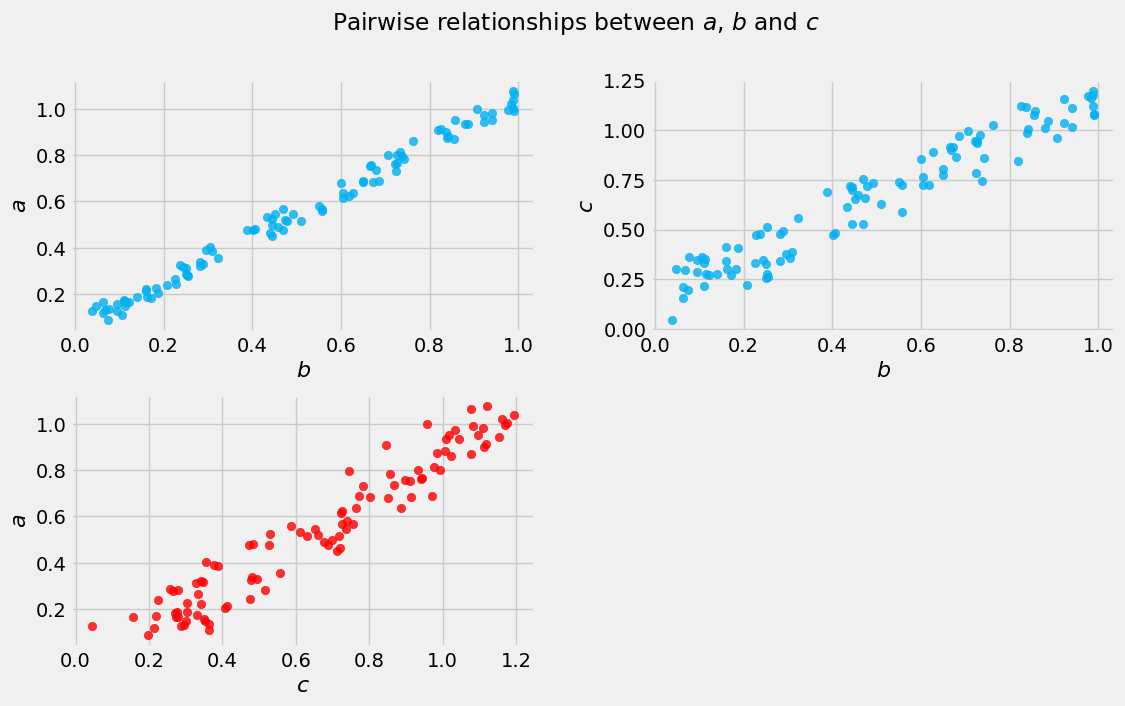

In [5]:
variables = {
    'a': a,
    'b': b,
    'c': c
}

plt.figure(figsize=(12, 7))

for i, (var_1, var_2) in enumerate([('b', 'a'), ('b', 'c'), ('c', 'a')]):

    color = COLORS[1]

    if 'b' in [var_1, var_2]:
        color = COLORS[0]

    plt.subplot(2, 2, i + 1)
    plt.scatter(variables[var_1], variables[var_2], alpha=.8, color=color)

    plt.xlabel(f'${var_1}$', fontsize=16)
    plt.ylabel(f'${var_2}$', fontsize=16)

plt.suptitle('Pairwise relationships between $a$, $b$ and $c$')
plt.subplots_adjust(hspace=.25, wspace=.25)
plt.show()

## 2.2. 펄(Pearl)의 인과 추론


  * **1단계: 연관(Association)**:
  * **2단계: 중재(Intervention)**
  * **3단계: 반사실(Counterfactuals)**

### 2.2.1. 연관 (Association)

In [6]:
# 먼저, 구조적 인과 모델(SCM)을 구축한다
class BookSCM:

    def __init__(self, random_seed=None):
        self.random_seed = random_seed
        self.u_0 = stats.uniform()
        self.u_1 = stats.norm()

    def sample(self, sample_size=100):
        """SCM에서 샘플링한다"""
        if self.random_seed:
            np.random.seed(self.random_seed)

        u_0 = self.u_0.rvs(sample_size)
        u_1 = self.u_1.rvs(sample_size)
        a = u_0 > .61
        b = (a + .5 * u_1) > .2

        return a, b

In [7]:
# SCM을 초기화한다
scm = BookSCM(random_seed=45)

# ...그리고 샘플링한다
buy_book_a, buy_book_b = scm.sample(100)

# 정상 동작 확인
buy_book_a.shape, buy_book_b.shape

((100,), (100,))

In [8]:
# 확률을 계산한다
proba_book_a = buy_book_a.sum() / buy_book_a.shape[0]
proba_book_b = buy_book_b.sum() / buy_book_b.shape[0]

print(f'Probability of buying book A: {proba_book_a:0.3f}')
print(f'Probability of buying book B: {proba_book_b:0.3f}')

# ...그리고 조건부 확률을 계산한다
proba_book_a_given_book_b = np.where(buy_book_b, buy_book_a, 0).sum() / buy_book_b.sum()
proba_book_b_given_book_a = np.where(buy_book_a, buy_book_b, 0).sum() / buy_book_a.sum()

print(f'Probability of buying book A given B: {proba_book_a_given_book_b:0.3f}')
print(f'Probability of buying book B given A: {proba_book_b_given_book_a:0.3f}')

Probability of buying book A: 0.390
Probability of buying book B: 0.580
Probability of buying book A given B: 0.638
Probability of buying book B given A: 0.949


### 2.2.2. 중재 (Intervention)

In [9]:
SAMPLE_SIZE = 100

np.random.seed(45)

u_0 = np.random.randn(SAMPLE_SIZE)
u_1 = np.random.randn(SAMPLE_SIZE)
a = u_0
b = 5 * a + u_1

r, p = stats.pearsonr(a, b)

print(f'Mean of B before any intervention: {b.mean():.3f}')
print(f'Variance of B before any intervention: {b.var():.3f}')
print(f'Correlation between A and B:\nr = {r:.3f}; p = {p:.3f}\n')

a = np.array([1.5] * SAMPLE_SIZE)
b = 5 * a + u_1

print(f'Mean of B after the intervention on A: {b.mean():.3f}')
print(f'Variance of B after the intervention on A: {b.var():.3f}\n')

a = u_0
b = np.random.randn(SAMPLE_SIZE)

r, p = stats.pearsonr(a, b)

print(f'Mean of B after the intervention on B: {b.mean():.3f}')
print(f'Variance of B after the intervention on B: {b.var():.3f}')
print(f'Correlation between A and B after intervening on B:\nr = {r:.3f}; p = {p:.3f}\n')

Mean of B before any intervention: -0.620
Variance of B before any intervention: 22.667
Correlation between A and B:
r = 0.978; p = 0.000

Mean of B after the intervention on A: 7.575
Variance of B after the intervention on A: 1.003

Mean of B after the intervention on B: 0.186
Variance of B after the intervention on B: 0.995
Correlation between A and B after intervening on B:
r = -0.023; p = 0.821



### 2.2.3. 반사실 (Counterfactuals)

In [10]:
class CounterfactualSCM:

    def abduct(self, t, y):
        return (t + y - 1)/(2*t - 1)

    def modify(self, t):
        return lambda u: t * u + (t - 1) * (u - 1)

    def predict(self, u, t):
        return self.modify(t)(u)

반사실 추론의 세 단계를 수행하는 `CounterfactualSCM` 클래스를 정의한다.

  * **`abduct` (귀추)**: 관찰된 치료(`t`)와 결과(`y`)를 SCM 방정식에 대입하여 외생 변수 `u`를 역으로 계산한다.
  * **`modify` (중재)**: 가상의 치료(`t`) 값을 적용하여 수정된 인과 모델(함수)을 생성한다.
  * **`predict` (예측)**: `abduct` 단계에서 추론한 `u`값과 `modify` 단계에서 생성한 수정된 모델을 사용하여 반사실적 결과를 계산한다.

<!-- end list -->

In [11]:
coffee = CounterfactualSCM()
t = 1
y = 1
u = coffee.abduct(t=t, y=y)
u

1.0

반사실 추론의 첫 번째 단계인 '귀추'를 수행한다. "치료를 받았고(`t=1`), 결과적으로 회복되었다(`y=1`)"는 관찰된 사실을 바탕으로, 이 개인의 특성을 나타내는 외생 변수 `u`의 값을 추론한다.


In [12]:
coffee.predict(u=u, t=0)

0.0

## 2.3. 상관관계 없는 인과관계 - 플롯

### 2.3.1. 비단조적 사례 (Non-monotonic case)

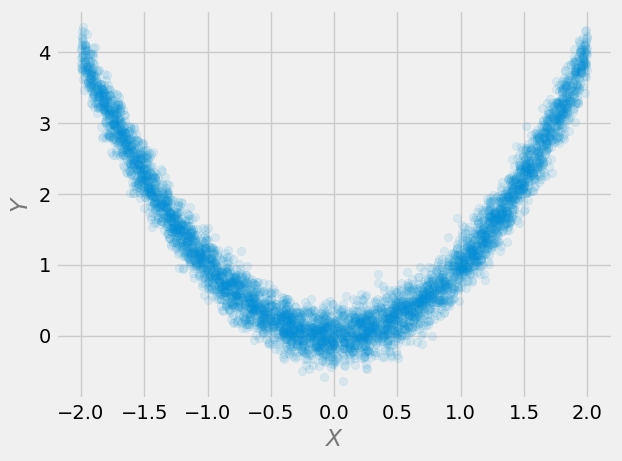

In [13]:
x = np.random.uniform(-2, 2, 5000)
y = x**2 + 0.2*np.random.randn(len(x))

plt.scatter(x, y, alpha=.1)
plt.xlabel('$X$', alpha=.5)
plt.ylabel('$Y$', alpha=.5)
plt.show()

In [14]:
# 상관 계수
stats.spearmanr(x, y)

SignificanceResult(statistic=np.float64(-0.017571125214845006), pvalue=np.float64(0.21414381254206408))

### 2.3.2. 잘못된 샘플링 사례 (Bad sampling case)

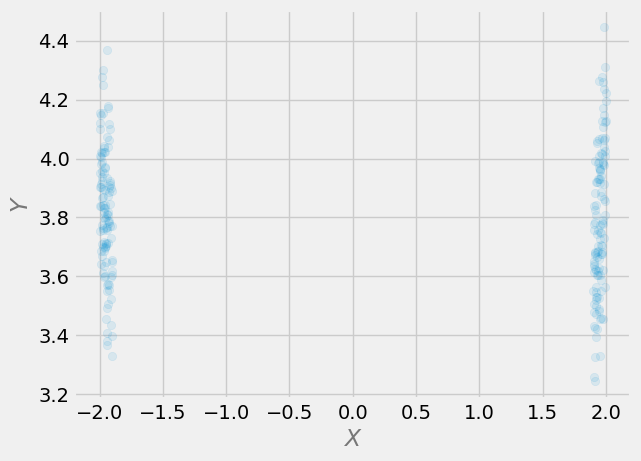

In [15]:
# 초기 x를 가져온다
x = np.random.uniform(-2, 2, 5000)

# 샘플을 필터링한다
x = x[np.where((x < -1.9) | (x > 1.9), True, False)]

# y를 가져온다
y = x**2 + 0.2*np.random.randn(len(x))

plt.scatter(x, y, alpha=.1)
plt.xlabel('$X$', alpha=.5)
plt.ylabel('$Y$', alpha=.5)
plt.show()

In [16]:
# 상관 계수
stats.spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.0075097809299378045), pvalue=np.float64(0.9092243672544423))